# Homework Reflections 1–4

DX702 — Experimental Design and Causality

Each reflection has two written answer paragraphs, followed by its supporting
code and results. The library example is simulated; the other data-based
answers use the supplied homework CSVs. Run the notebook from top to bottom.

## Setup

In [1]:
from pathlib import Path
import hashlib
import importlib.metadata
import platform

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.neighbors import NearestNeighbors
from IPython.display import display

# If needed: %pip install numpy pandas scipy matplotlib scikit-learn
pd.set_option('display.precision', 6)
pd.set_option('display.max_columns', 12)
pd.set_option('display.max_rows', 25)
plt.rcParams.update({
    'figure.figsize': (9, 4.8), 'figure.dpi': 110, 'font.size': 11,
    'axes.titlesize': 13, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#E5E7EB', 'axes.axisbelow': True,
    'text.color': '#1F2937', 'axes.labelcolor': '#1F2937',
})
BLUE, GOLD, DARK = '#2563EB', '#B7791F', '#374151'
source_paths = {}

def load_csv(filename):
    # Find the source from the project folder or any of its subfolders.
    for folder in (Path.cwd(), *Path.cwd().parents):
        path = folder / filename
        if path.is_file():
            frame = pd.read_csv(path)
            if not all(pd.api.types.is_numeric_dtype(frame[c]) for c in frame):
                raise TypeError(f'{filename} contains nonnumeric analysis data.')
            if not np.isfinite(frame.to_numpy()).all():
                raise ValueError(f'{filename} contains missing or infinite data.')
            source_paths[filename] = path.resolve()
            return frame
    raise FileNotFoundError(f'Cannot find {filename} above the working directory.')

def show_table(frame, formats=None):
    display(frame.reset_index(drop=True))

## Homework reflection 1

### 1. Is the farthest match meaningful? How can this be decided?

The farthest nearest-neighbor match has distance **0.210217** in Z: a treated
observation with Z = **0.988374** is matched to a control with Z = **0.778157**,
the largest Z among all controls. I would regard this as a poor match because
the treated observation lies beyond the control group's observed range and
the distance exceeds the quiz's 0.2 radius. It is also about **0.837 pooled
standard deviations** of Z, compared with a median matching distance of
0.013260. There is no universally meaningful distance cutoff: I would assess
the scale and outcome relevance of Z, overlap, post-matching covariate balance,
and sensitivity to a prespecified caliper. Matching cannot fix a lack of
comparable controls or remove unmeasured confounding.

In [2]:
matching_data = load_csv('homework_1.2.csv')
assert set(matching_data['X'].unique()) == {0, 1}
treated = matching_data.loc[matching_data['X'] == 1].copy().reset_index(drop=True)
controls = matching_data.loc[matching_data['X'] == 0].copy().reset_index(drop=True)

nearest = NearestNeighbors(n_neighbors=1).fit(controls[['Z']])
distances, indices = nearest.kneighbors(treated[['Z']])
distances = distances[:, 0]
farthest = int(distances.argmax())
farthest_control = int(indices[farthest, 0])
pooled_sd = np.sqrt((treated['Z'].var(ddof=1) + controls['Z'].var(ddof=1)) / 2)

distance_summary = pd.DataFrame({
    'Measure': ['Farthest distance', 'Treated Z for farthest match',
                'Matched control Z', 'Largest control Z', 'Median distance',
                'Farthest distance / pooled SD', 'Treated units beyond a 0.2 caliper'],
    'Value': [distances[farthest], treated.loc[farthest, 'Z'],
              controls.loc[farthest_control, 'Z'], controls['Z'].max(),
              np.median(distances), distances[farthest] / pooled_sd,
              int((distances > 0.2).sum())],
})
show_table(distance_summary)
np.testing.assert_allclose(distances[farthest],
    abs(treated.loc[farthest, 'Z'] - controls.loc[farthest_control, 'Z']), atol=1e-12)

,Measure,Value
0,Farthest distance,0.210217
1,Treated Z for farthest match,0.988374
2,Matched control Z,0.778157
3,Largest control Z,0.778157
4,Median distance,0.013260
5,Farthest distance / pooled SD,0.836792
6,Treated units beyond a 0.2 caliper,2.000000


### 2. Invent and explain another matching method

I propose **up to three nearest controls within a 0.2 caliper, with inverse-distance
weights**. For each treated observation, I retain its three closest controls
only when their Z distance is at most 0.2, assign weights proportional to
1/(distance + 0.01), and use their weighted mean Y as its counterfactual.
The 0.01 term prevents division by zero, controls may be reused across treated
observations, and treated observations with no eligible control are excluded
and counted. This combines a limit on poor matches with greater weight on
closer controls. It retains **46 of 48 treated observations**, gives an average
treated-minus-matched outcome difference of **0.542904**, and leaves a Z
standardized mean difference of about **0.171**. Thus, it targets the retained
treated observations and still has residual imbalance; changing the caliper,
neighbor count, or weight adjustment could change the result.

In [3]:
CALIPER = 0.2
MAX_CONTROLS = 3
WEIGHT_OFFSET = 0.01
neighbors = NearestNeighbors(n_neighbors=MAX_CONTROLS).fit(controls[['Z']])
candidate_distances, candidate_indices = neighbors.kneighbors(treated[['Z']])

matched_rows = []
for treated_index in range(len(treated)):
    eligible = candidate_distances[treated_index] <= CALIPER
    if not eligible.any():
        continue
    selected_distances = candidate_distances[treated_index, eligible]
    selected_controls = controls.iloc[candidate_indices[treated_index, eligible]]
    weights = 1 / (selected_distances + WEIGHT_OFFSET)
    weights /= weights.sum()
    np.testing.assert_allclose(weights.sum(), 1)
    matched_y = np.dot(weights, selected_controls['Y'])
    matched_z = np.dot(weights, selected_controls['Z'])
    matched_rows.append({
        'Treated row': treated_index, 'Controls used': len(weights),
        'Treated Z': treated.loc[treated_index, 'Z'], 'Matched Z': matched_z,
        'Outcome difference': treated.loc[treated_index, 'Y'] - matched_y,
    })

custom_matches = pd.DataFrame(matched_rows)
custom_effect = custom_matches['Outcome difference'].mean()
matched_smd = (custom_matches['Treated Z'] - custom_matches['Matched Z']).mean() / pooled_sd
show_table(pd.DataFrame({
    'Retained treated': [len(custom_matches)],
    'Excluded treated': [len(treated) - len(custom_matches)],
    'Control assignments (reuse allowed)': [custom_matches['Controls used'].sum()],
    'Matched outcome difference': [custom_effect], 'Matched Z SMD': [matched_smd],
}))

,Retained treated,Excluded treated,Control assignments (reuse allowed),Matched outcome difference,Matched Z SMD
0,46,2,126,0.542904,0.170784


## Homework reflection 2

### 1. Invent a situation that would use fixed effects

Suppose I study whether employee training hours increase monthly productivity
at several factories. A model such as
$Productivity_{it}=\alpha_i+\lambda_t+\beta Training_{it}+\varepsilon_{it}$
includes a factory fixed effect $\alpha_i$ to absorb stable differences in
machinery, location, and management, and a month fixed effect $\lambda_t$ to
absorb common seasonal or demand shocks. The training coefficient is estimated
from changes within factories after accounting for common month changes.
This is useful when consistently high-productivity factories also provide
more training, although time-varying confounders, such as simultaneous machinery
upgrades, would still threaten a causal interpretation.

### 2. Bootstrap the variance of the Pareto sample mean as sample size grows

I used a Pareto Type I distribution with minimum **1** and shape **3**, generated
as `1 + rng.pareto(3)`, so its mean is 1.5 and its variance is 0.75. For each
sample size (100, 500, 2,000, and 10,000), the code draws one original sample,
resamples it with replacement 4,000 times at the same size, and computes the
variance of the bootstrap means using `ddof=1`. With seed 42, those variances
are approximately **0.003799, 0.000852, 0.000274, and 0.0000546**: they get
smaller as sample size increases. The population benchmark is
$Var(\bar X)=0.75/n$; the exact conditional bootstrap benchmark is the original
sample's empirical variance (`ddof=0`) divided by n. They differ because a
finite heavy-tailed sample may omit rare extremes. The finite-variance argument
requires shape greater than 2; for a Pareto shape at or below 2, population
variance is infinite and this usual variance comparison does not apply.

In [4]:
PARETO_SHAPE = 3.0
PARETO_MINIMUM = 1.0
SAMPLE_SIZES = [100, 500, 2_000, 10_000]
BOOTSTRAPS = 4_000
BATCH_SIZE = 100
bootstrap_rng = np.random.default_rng(42)
population_variance = (
    PARETO_SHAPE * PARETO_MINIMUM ** 2
    / ((PARETO_SHAPE - 1) ** 2 * (PARETO_SHAPE - 2))
)

bootstrap_rows = []
for sample_size in SAMPLE_SIZES:
    original_sample = PARETO_MINIMUM * (1 + bootstrap_rng.pareto(PARETO_SHAPE, sample_size))
    bootstrap_means = np.empty(BOOTSTRAPS)
    # Batches keep memory bounded even at the largest sample size.
    for start in range(0, BOOTSTRAPS, BATCH_SIZE):
        count = min(BATCH_SIZE, BOOTSTRAPS - start)
        indices = bootstrap_rng.integers(0, sample_size, size=(count, sample_size))
        bootstrap_means[start:start + count] = original_sample[indices].mean(axis=1)
    estimated_variance = bootstrap_means.var(ddof=1)
    conditional_variance = original_sample.var(ddof=0) / sample_size
    bootstrap_rows.append({
        'Sample size': sample_size,
        'Bootstrap variance': estimated_variance,
        'Conditional bootstrap benchmark': conditional_variance,
        'Population benchmark (0.75/n)': population_variance / sample_size,
    })

bootstrap_results = pd.DataFrame(bootstrap_rows)
show_table(bootstrap_results)
assert population_variance == 0.75
assert np.isfinite(bootstrap_results.to_numpy()).all()

,Sample size,Bootstrap variance,Conditional bootstrap benchmark,Population benchmark (0.75/n)
0,100,0.003799,0.003847,0.007500
1,500,0.000852,0.000847,0.001500
2,2000,0.000274,0.000262,0.000375
3,10000,0.000055,0.000056,0.000075


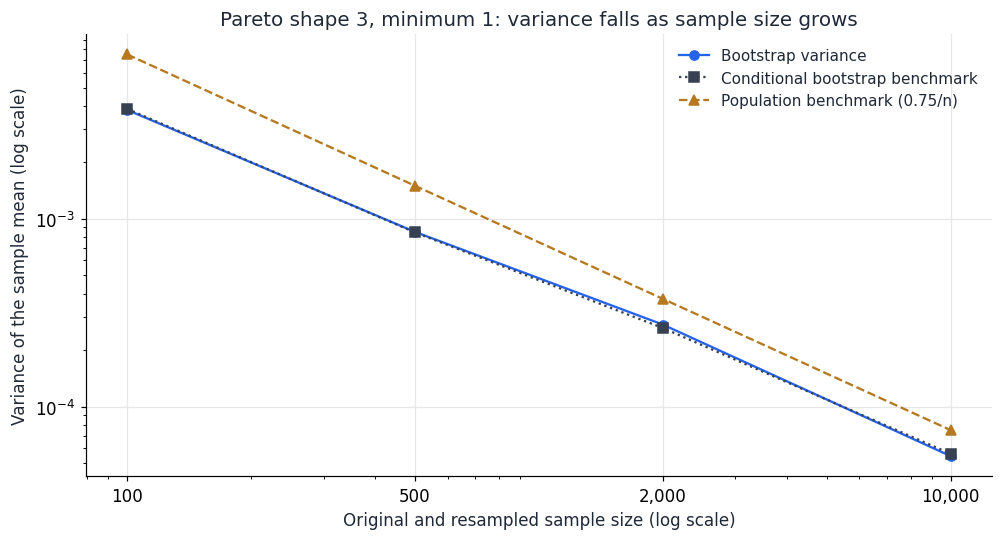

In [5]:
fig, ax = plt.subplots(figsize=(9, 4.8), constrained_layout=True)
for column, color, marker, linestyle in [
    ('Bootstrap variance', BLUE, 'o', '-'),
    ('Conditional bootstrap benchmark', DARK, 's', ':'),
    ('Population benchmark (0.75/n)', GOLD, '^', '--'),
]:
    ax.plot(bootstrap_results['Sample size'], bootstrap_results[column],
            color=color, marker=marker, linestyle=linestyle, label=column)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xticks(SAMPLE_SIZES, ['100', '500', '2,000', '10,000'])
ax.set_xlabel('Original and resampled sample size (log scale)')
ax.set_ylabel('Variance of the sample mean (log scale)')
ax.set_title('Pareto shape 3, minimum 1: variance falls as sample size grows')
ax.legend(frameon=False, fontsize=10)
plt.show()

## Homework reflection 3

### 1. How could the event study test for a change in the second derivative?

Center time at the event, $x=t-50$, let $D=1[t\geq50]$, and fit
$Y=\alpha+\beta x+\kappa x^2+\delta D+\gamma xD+\eta x^2D+\varepsilon$.
This allows a level jump, slope change, and curvature change simultaneously.
The second derivative is $2\kappa$ before the event and $2(\kappa+\eta)$
afterward, so its discontinuity is **$2\eta$**. Test $H_0:\eta=0$ with the
regression t test, or compare the models with and without $x^2D$ using a nested
F test. The standard error of the estimated second-derivative change is twice
the standard error of $\hat\eta$. Applied to the supplied Week 3 series with
conventional OLS standard errors, the p-values are **0.979, 0.154, and 0.776**
for value1, value2, and value3; none gives evidence of a curvature change at 5%.
Serially correlated errors would require suitable time-series standard errors.

In [6]:
event_data = load_csv('homework_3.1.csv')
centered_time = event_data['time'].to_numpy() - 50
post_event = (centered_time >= 0).astype(float)
quadratic_design = np.column_stack([
    np.ones(len(event_data)), centered_time, centered_time ** 2,
    post_event, centered_time * post_event, centered_time ** 2 * post_event,
])
curvature_rows = []
for name in ['value1', 'value2', 'value3']:
    outcome = event_data[name].to_numpy()
    beta = np.linalg.lstsq(quadratic_design, outcome, rcond=None)[0]
    residual = outcome - quadratic_design @ beta
    residual_df = len(outcome) - quadratic_design.shape[1]
    residual_variance = (residual @ residual) / residual_df
    covariance = residual_variance * np.linalg.inv(quadratic_design.T @ quadratic_design)
    eta = beta[-1]
    eta_se = np.sqrt(covariance[-1, -1])
    p_value = 2 * stats.t.sf(abs(eta / eta_se), residual_df)
    curvature_rows.append({'Series': name, 'Second derivative before': 2 * beta[2],
        'Second derivative after': 2 * (beta[2] + eta),
        'Second derivative change': 2 * eta, 'Change SE': 2 * eta_se, 'p-value': p_value})

    # Separate quadratic regressions must give the same two curvatures.
    for after in [False, True]:
        mask = (post_event == int(after))
        separate = np.polyfit(centered_time[mask], outcome[mask], deg=2)
        np.testing.assert_allclose(2 * separate[0], 2 * (beta[2] + int(after) * eta), atol=1e-10)

curvature_results = pd.DataFrame(curvature_rows)
show_table(curvature_results)

,Series,Second derivative before,Second derivative after,Second derivative change,Change SE,p-value
0,value1,0.000768,0.000822,0.000054,0.002069,0.979315
1,value2,-0.000609,0.002584,0.003193,0.002220,0.153785
2,value3,0.000069,-0.000519,-0.000589,0.002058,0.775529


### 2. Create a differences-in-differences scenario and show the treatment effect

In this **simulated example**, 100 libraries extend their evening hours and
100 comparison libraries keep their existing hours. Weekly visits rise from
**100.41 to 124.44** in treated libraries and from **79.19 to 84.27** in controls,
giving a DiD estimate of **(124.44 − 100.41) − (84.27 − 79.19) ≈ 18.94 additional
visits per library per week**. The simulation gives both groups the same
untreated increase of 5 visits and assigns a true added treatment effect of
20 visits. To account for repeated observations on each library, I compare
each library's after-minus-before change across groups; a Welch comparison
gives a **95% interval of [16.97, 20.92]** and **p ≈ 4.94 × 10⁻⁴⁶**, supporting
a nonzero effect in these simulated data. Parallel untreated trends hold by
construction here; real libraries would require evidence for that assumption
and checks for other changes or spillovers.

In [7]:
simulation_rng = np.random.default_rng(42)
libraries_per_group = 100
treated_library = np.repeat([0, 1], libraries_per_group)
number_of_libraries = len(treated_library)
baseline = 80 + 20 * treated_library + simulation_rng.normal(0, 10, number_of_libraries)
before = baseline + simulation_rng.normal(0, 5, number_of_libraries)
after = (baseline + 5 + 20 * treated_library
         + simulation_rng.normal(0, 5, number_of_libraries))
# These are simulated average weekly visit measures, so fractional values are allowed.
library_data = pd.DataFrame({'library_id': np.arange(number_of_libraries),
    'treated': treated_library, 'before': before, 'after': after})
library_data['change'] = library_data['after'] - library_data['before']
library_means = library_data.groupby('treated')[['before', 'after']].mean()
did_effect = ((library_means.loc[1, 'after'] - library_means.loc[1, 'before'])
              - (library_means.loc[0, 'after'] - library_means.loc[0, 'before']))

treated_changes = library_data.loc[library_data['treated'] == 1, 'change']
control_changes = library_data.loc[library_data['treated'] == 0, 'change']
treated_variance = treated_changes.var(ddof=1) / len(treated_changes)
control_variance = control_changes.var(ddof=1) / len(control_changes)
did_se = np.sqrt(treated_variance + control_variance)
welch_df = (treated_variance + control_variance) ** 2 / (
    treated_variance ** 2 / (len(treated_changes) - 1)
    + control_variance ** 2 / (len(control_changes) - 1)
)
did_p = 2 * stats.t.sf(abs(did_effect / did_se), welch_df)
did_ci = did_effect + stats.t.ppf([.025, .975], welch_df) * did_se
show_table(library_means.reset_index().rename(columns={'treated': 'Treated library'}))
show_table(pd.DataFrame({'DiD estimate': [did_effect], 'SE of library changes': [did_se],
    '95% CI lower': [did_ci[0]], '95% CI upper': [did_ci[1]], 'p-value': [did_p]}))

# Check the DiD point estimate using the interaction regression on both periods.
long_library = library_data.melt(id_vars=['library_id', 'treated'],
    value_vars=['before', 'after'], var_name='period', value_name='visits')
post = long_library['period'].eq('after').astype(float)
design = np.column_stack([np.ones(len(long_library)), long_library['treated'],
                          post, long_library['treated'] * post])
regression_beta = np.linalg.lstsq(design, long_library['visits'], rcond=None)[0]
np.testing.assert_allclose(regression_beta[-1], did_effect, atol=1e-10)
np.testing.assert_allclose(stats.ttest_ind(treated_changes, control_changes, equal_var=False).pvalue,
                           did_p, rtol=1e-10)

,Treated library,before,after
0,0,79.185628,84.272881
1,1,100.406134,124.436874


,DiD estimate,SE of library changes,95% CI lower,95% CI upper,p-value
0,18.943487,1.000238,16.970789,20.916184,4.936754e-46


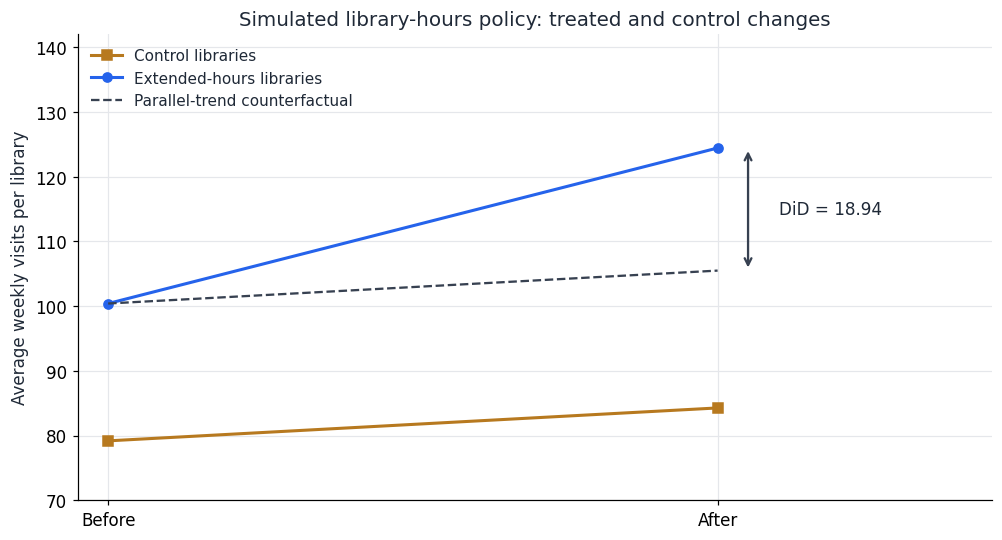

In [8]:
fig, ax = plt.subplots(figsize=(9, 4.8), constrained_layout=True)
control_means = library_means.loc[0, ['before', 'after']].to_numpy()
treated_means = library_means.loc[1, ['before', 'after']].to_numpy()
counterfactual = np.array([treated_means[0],
    treated_means[0] + control_means[1] - control_means[0]])
ax.plot([0, 1], control_means, 's-', color=GOLD, linewidth=2, label='Control libraries')
ax.plot([0, 1], treated_means, 'o-', color=BLUE, linewidth=2, label='Extended-hours libraries')
ax.plot([0, 1], counterfactual, '--', color=DARK, label='Parallel-trend counterfactual')
ax.annotate('', xy=(1.05, treated_means[1]), xytext=(1.05, counterfactual[1]),
            arrowprops={'arrowstyle': '<->', 'color': DARK, 'lw': 1.5})
ax.text(1.10, (treated_means[1] + counterfactual[1]) / 2, f'DiD = {did_effect:.2f}', va='center')
ax.set_xticks([0, 1], ['Before', 'After'])
ax.set_xlim(-.05, 1.45)
ax.set_ylim(70, 142)
ax.set_ylabel('Average weekly visits per library')
ax.set_title('Simulated library-hours policy: treated and control changes')
ax.legend(frameon=False, loc='upper left', fontsize=10)
plt.show()

## Homework reflection 4

### 1. Explain the W-interval IV calculation, show code, and discuss issues

I divided W into **20 equal-count quantile intervals**, each containing 250
observations. Within each interval, I computed the Z=1 minus Z=0 differences
in mean Y and mean X, divided the Y difference by the X difference, and then
averaged the 20 ratios equally. The estimate is **1.505526**, compared with
**1.561859** from the overall ratio; using 10 and 40 intervals gives **1.508896**
and **1.510400**. I checked that both Z groups occur in every interval, that all
5,000 rows are retained, and that no X difference is near zero (the smallest
absolute difference is **0.833818**). Equal-count bins limit sparse-bin noise,
but the tail intervals are wider and W can still vary within a bin. More bins
can reduce that variation while producing unstable ratios if the first-stage
difference is small. The code therefore checks those issues explicitly; this
method also requires W, whereas the overall IV ratio does not.

In [9]:
def effects_by_w(frame, number_of_bins):
    working = frame.assign(w_bin=pd.qcut(frame['W'], q=number_of_bins))
    grouped = working.groupby(['w_bin', 'Z'], observed=True)
    means = grouped[['X', 'Y']].mean().unstack('Z')
    counts = grouped.size().unstack('Z', fill_value=0)
    if not (counts > 0).all().all():
        raise ValueError('A W interval does not contain both instrument levels.')
    differences_x = means['X'][1] - means['X'][0]
    differences_y = means['Y'][1] - means['Y'][0]
    if np.isclose(differences_x, 0).any():
        raise ValueError('An interval has a numerically negligible first-stage difference.')
    result = pd.DataFrame({
        'W interval': means.index.astype(str),
        'Mean W': working.groupby('w_bin', observed=True)['W'].mean().to_numpy(),
        'N (Z=0)': counts[0].to_numpy(), 'N (Z=1)': counts[1].to_numpy(),
        'Delta X': differences_x.to_numpy(), 'Delta Y': differences_y.to_numpy(),
        'IV effect': (differences_y / differences_x).to_numpy(),
    })
    assert result[['N (Z=0)', 'N (Z=1)']].to_numpy().sum() == len(frame)
    return result


iv_data = load_csv('homework_4.1.csv')
assert set(iv_data['Z'].unique()) == {0, 1}
w_interval_results = effects_by_w(iv_data, 20)
conditional_iv = w_interval_results['IV effect'].mean()
overall_means = iv_data.groupby('Z')[['X', 'Y']].mean()
overall_iv = ((overall_means.loc[1, 'Y'] - overall_means.loc[0, 'Y'])
              / (overall_means.loc[1, 'X'] - overall_means.loc[0, 'X']))
show_table(w_interval_results)
print(f'Mean of 20 W-interval ratios: {conditional_iv:.6f}')
print(f'Overall IV ratio: {overall_iv:.6f}')

,W interval,Mean W,N (Z=0),N (Z=1),Delta X,Delta Y,IV effect
0,"(-3.304, -1.584]",-2.006390,137,113,0.966625,1.631885,1.688229
1,"(-1.584, -1.277]",-1.417961,125,125,1.122390,1.515458,1.350206
2,"(-1.277, -1.042]",-1.154357,130,120,1.056222,1.387932,1.314053
3,"(-1.042, -0.855]",-0.948417,121,129,0.914857,1.179224,1.288970
4,"(-0.855, -0.698]",-0.775636,129,121,0.994000,1.618208,1.627976
5,"(-0.698, -0.547]",-0.622287,133,117,0.966086,1.541029,1.595126
6,"(-0.547, -0.401]",-0.474302,119,131,0.927924,1.559258,1.680372
7,"(-0.401, -0.277]",-0.338176,121,129,0.833818,1.294000,1.551898
8,"(-0.277, -0.149]",-0.211072,134,116,0.941400,1.307982,1.389401
9,"(-0.149, -0.0322]",-0.090246,116,134,1.055303,1.582737,1.499795


Mean of 20 W-interval ratios: 1.505526
Overall IV ratio: 1.561859


In [10]:
w_sensitivity = []
for number in [10, 20, 40]:
    result = effects_by_w(iv_data, number)
    w_sensitivity.append({'W intervals': number, 'Mean IV effect': result['IV effect'].mean(),
        'Smallest absolute Delta X': result['Delta X'].abs().min(),
        'Minimum observations in a Z group': result[['N (Z=0)', 'N (Z=1)']].to_numpy().min()})
show_table(pd.DataFrame(w_sensitivity))

,W intervals,Mean IV effect,Smallest absolute Delta X,Minimum observations in a Z group
0,10,1.508896,0.880740,235
1,20,1.505526,0.833818,113
2,40,1.510400,0.663936,51


### 2. Plot observed college outcomes and logistic probabilities near score 80

For each dataset, I restrict scores to **70–90**, group students into one-point
score bins, and plot each bin's **mean Y**, which is its observed admission rate,
at the bin's mean score. The vertical bars are 95% Wilson intervals for these
binomial proportions. I compare these rates with a local logistic regression,
$\operatorname{logit}(p)=\alpha+\beta(X-80)+\delta D+\gamma(X-80)D$,
where $D=1[X\geq80]$, plotting the two sides separately to preserve the cutoff
jump. This displays the information in the binary outcomes without piling
100,000 points at zero and one. The fitted upward probability jumps at 80 are
about **29.52 percentage points for dataset a** and **19.74 percentage points
for dataset b**. Dataset a is nearly flat on each side, while dataset b's local
admission probability increases with score and has a flatter slope immediately
after 80. These are local fitted associations; a causal course effect additionally
requires the regression-discontinuity assumptions and the course-assignment rule.

In [11]:
CUTOFF = 80
datasets = {}
for label, filename, names in [
    ('Dataset a', 'homework_4.2.a.csv', ['X', 'Y']),
    ('Dataset b', 'homework_4.2.b.csv', ['X2', 'Y2']),
]:
    frame = load_csv(filename)[names].copy()
    frame.columns = ['score', 'admitted']
    assert set(frame['admitted'].unique()) == {0, 1}
    datasets[label] = frame

def make_design(score):
    centered = np.asarray(score) - CUTOFF
    after = (centered >= 0).astype(float)
    return np.column_stack([np.ones(len(centered)), centered, after, centered * after])

In [12]:
from scipy.optimize import minimize
from scipy.special import expit

def logistic_fit(frame, bandwidth=None):
    local = frame if bandwidth is None else frame.loc[(frame['score'] - CUTOFF).abs() <= bandwidth]
    X = make_design(local['score'])
    y = local['admitted'].to_numpy()

    def objective(beta):
        eta = X @ beta
        return np.sum(np.logaddexp(0, eta) - y * eta)

    def gradient(beta):
        return X.T @ (expit(X @ beta) - y)

    def hessian(beta):
        probability = expit(X @ beta)
        return X.T @ ((probability * (1 - probability))[:, None] * X)

    result = minimize(objective, np.zeros(4), jac=gradient, hess=hessian,
                      method='Newton-CG', options={'xtol': 1e-10, 'maxiter': 100})
    if not result.success:
        raise RuntimeError(result.message)
    if np.max(np.abs(gradient(result.x))) / len(local) > 1e-7:
        raise RuntimeError('Logistic score equations did not converge sufficiently.')
    return {'beta': result.x, 'n': len(local), 'bandwidth': bandwidth}

def probability_at_cutoff(model):
    beta = model['beta']
    p_before = expit(beta[0])
    p_after = expit(beta[0] + beta[2])
    return {'Probability before': p_before, 'Probability after': p_after,
            'Probability jump': p_after - p_before,
            'Probability slope before': p_before * (1 - p_before) * beta[1],
            'Probability slope after': p_after * (1 - p_after) * (beta[1] + beta[3])}


BANDWIDTH = 10
local_models = {label: logistic_fit(frame, BANDWIDTH) for label, frame in datasets.items()}
local_results = pd.DataFrame([
    {'Dataset': label, 'Rows in 70–90': model['n'], **probability_at_cutoff(model)}
    for label, model in local_models.items()
])
show_table(local_results)

,Dataset,Rows in 70–90,Probability before,Probability after,Probability jump,Probability slope before,Probability slope after
0,Dataset a,68233,0.305246,0.600404,0.295158,0.000367,0.000466
1,Dataset b,68139,0.701400,0.898843,0.197443,0.009440,0.006068


In [13]:
from matplotlib.ticker import PercentFormatter

def binned_rates(frame, edges):
    working = frame.assign(score_bin=pd.cut(frame['score'], edges, right=False))
    rates = working.groupby('score_bin', observed=True).agg(
        score=('score', 'mean'), rate=('admitted', 'mean'), n=('admitted', 'size')
    ).reset_index(drop=True)
    # Wilson 95% intervals for each observed binomial admission rate.
    z = stats.norm.ppf(.975)
    denominator = 1 + z ** 2 / rates['n']
    center = (rates['rate'] + z ** 2 / (2 * rates['n'])) / denominator
    half = z * np.sqrt(rates['rate'] * (1 - rates['rate']) / rates['n']
                        + z ** 2 / (4 * rates['n'] ** 2)) / denominator
    rates['lower'] = center - half
    rates['upper'] = center + half
    return rates

def plot_observed_rates(ax, rates):
    errors = np.vstack([rates['rate'] - rates['lower'], rates['upper'] - rates['rate']])
    # At a rate of 100%, roundoff can make the zero-length upper error slightly negative.
    assert errors.min() > -1e-12
    ax.errorbar(rates['score'], rates['rate'],
                yerr=np.maximum(errors, 0),
                fmt='o', color=DARK, markersize=4, capsize=2,
                label='Observed bin rate (95% Wilson CI)')

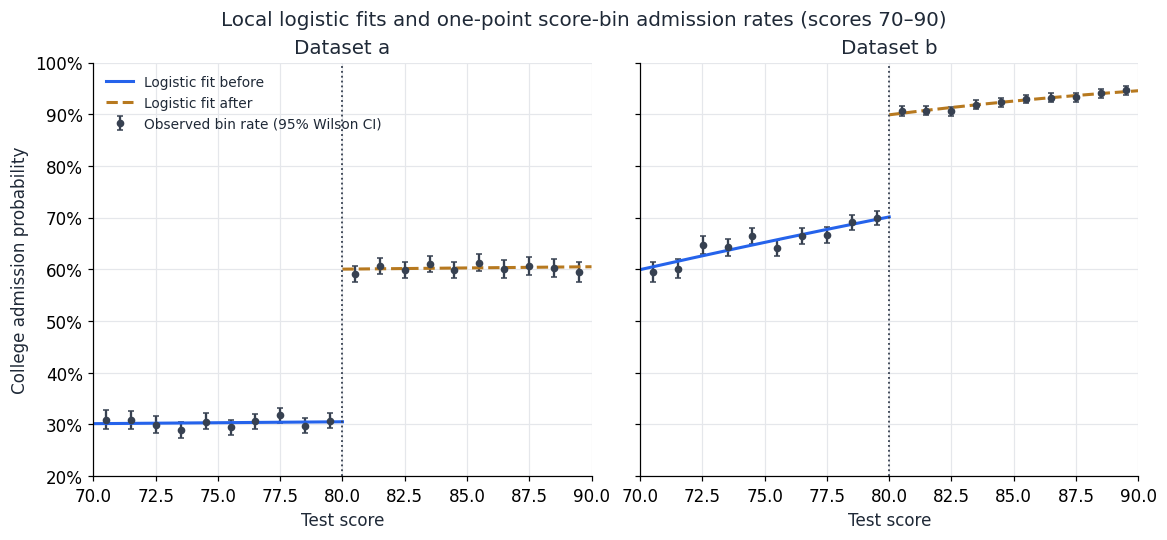

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.8), sharey=True, constrained_layout=True)
for ax, (label, frame) in zip(axes, datasets.items()):
    plot_observed_rates(ax, binned_rates(frame, np.arange(70, 91, 1)))
    beta = local_models[label]['beta']
    for low, high, color, linestyle, line_label in [
        (70, 80 - 1e-6, BLUE, '-', 'Logistic fit before'),
        (80, 90, GOLD, '--', 'Logistic fit after'),
    ]:
        scores = np.linspace(low, high, 200)
        ax.plot(scores, expit(make_design(scores) @ beta), color=color,
                linestyle=linestyle, linewidth=2, label=line_label)
    ax.axvline(CUTOFF, color=DARK, linestyle=':', linewidth=1.2)
    ax.set_title(label)
    ax.set_xlabel('Test score')
    ax.set_xlim(70, 90)
    ax.set_ylim(.2, 1)
    ax.yaxis.set_major_formatter(PercentFormatter(1))
axes[0].set_ylabel('College admission probability')
axes[0].legend(frameon=False, fontsize=9, loc='upper left')
fig.suptitle('Local logistic fits and one-point score-bin admission rates (scores 70–90)', fontsize=13)
plt.show()

## Source files and execution environment

In [15]:
for filename, path in source_paths.items():
    print(f'{filename}: SHA-256 {hashlib.sha256(path.read_bytes()).hexdigest()}')
print('Python:', platform.python_version())
for package in ['numpy', 'pandas', 'scipy', 'matplotlib', 'scikit-learn']:
    print(f'{package}: {importlib.metadata.version(package)}')

homework_1.2.csv: SHA-256 6d7b77cb4f423742c06973506e26fb845ef169a554146d802b8ff0f070963eb3
homework_3.1.csv: SHA-256 458ca6aefd8268173ad081e8325251aebbe235519004715abe61336858e8427b
homework_4.1.csv: SHA-256 0cf5f0d0380a2591dd5f9411933466eb488f5bd77832d3fa16638addcb5a5832
homework_4.2.a.csv: SHA-256 b9f5670015bde68e1ad2628e00a13353abc57bf15694279a2b5685e9b10acbb5
homework_4.2.b.csv: SHA-256 3707084a9c950df1d5ed1d6a89b83bffea2c9dd92a231d55f2cb3619f186edc7
Python: 3.13.5
numpy: 2.4.1


pandas: 3.0.0
scipy: 1.17.0
matplotlib: 3.10.8
scikit-learn: 1.8.0
